In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msfm.utils import catalog, files

In [2]:
conf = files.load_config("../configs/v16/default.yaml")
n_side = conf["analysis"]["n_side"]
n_pix = hp.nside2npix(n_side)

### Build metacal (lensing) maps

Builds and caches the tomographic shear maps both with and without the spin-2 footprint-rotation correction (`apply_shear_rotation`).

In [3]:
wl_gamma_map, wl_count_map = catalog.build_metacal_map_from_cat(conf)
wl_gamma_map_no_psi_rot, _ = catalog.build_metacal_map_from_cat(conf, apply_shear_rotation=False)

26-06-15 09:21:13   catalog.py INF   Cache not found, computing metacal maps 


26-06-15 09:21:23   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13543 
26-06-15 09:21:23   catalog.py INF   Metacalibration bin 1 
26-06-15 09:21:23   catalog.py INF   N_gal = 24940465, n_eff = 1.476 [arcmin^-2] 
26-06-15 09:21:23   catalog.py INF   mean(e1) = 3.22e-04, mean(e2) = 1.60e-04 
26-06-15 09:21:23   catalog.py INF   sigma_e (H12) = 0.245, sigma_e (C13) = 0.187 
26-06-15 09:21:32   catalog.py INF   mean(R_gamma) = 0.7636 
26-06-15 09:21:33   catalog.py INF   z_mean (DNF) = 0.3305 
26-06-15 09:21:41   catalog.py INF   Metacalibration bin 2 
26-06-15 09:21:42   catalog.py INF   N_gal = 25280405, n_eff = 1.479 [arcmin^-2] 
26-06-15 09:21:42   catalog.py INF   mean(e1) = 3.36e-04, mean(e2) = 3.74e-05 
26-06-15 09:21:42   catalog.py INF   sigma_e (H12) = 0.265, sigma_e (C13) = 0.191 
26-06-15 09:21:43   catalog.py INF   mean(R_gamma) = 0.7182 
26-06-15 09:21:43   catalog.py INF   z_mean (DNF) = 0.5133 
26-06-15 09:21:52   catalog.py INF   Metacalibration bi

### Build maglim (clustering) map

In [4]:
gc_count_map = catalog.build_maglim_map_from_cat(conf)

26-06-15 09:22:45   catalog.py INF   Cache not found, computing maglim map 
26-06-15 09:22:47   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13546 
26-06-15 09:22:47   catalog.py INF   Maglim bin 1 
26-06-15 09:22:47   catalog.py INF   N_gal = 2236473, n_eff = 0.150 [arcmin^-2] 
26-06-15 09:22:47   catalog.py INF   Maglim bin 2 
26-06-15 09:22:47   catalog.py INF   N_gal = 1599500, n_eff = 0.107 [arcmin^-2] 
26-06-15 09:22:47   catalog.py INF   Maglim bin 3 
26-06-15 09:22:47   catalog.py INF   N_gal = 1627413, n_eff = 0.109 [arcmin^-2] 
26-06-15 09:22:48   catalog.py INF   Maglim bin 4 
26-06-15 09:22:48   catalog.py INF   N_gal = 2175184, n_eff = 0.146 [arcmin^-2] 
26-06-15 09:22:48   catalog.py INF   Saved maglim map to /users/athomsen/dlss/repos/multiprobe-simulation-forward-model/data/maglim_gc_count_map.npy 


### Quick sanity plots (bin 1)

/tmp/ipykernel_186331/3411826499.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


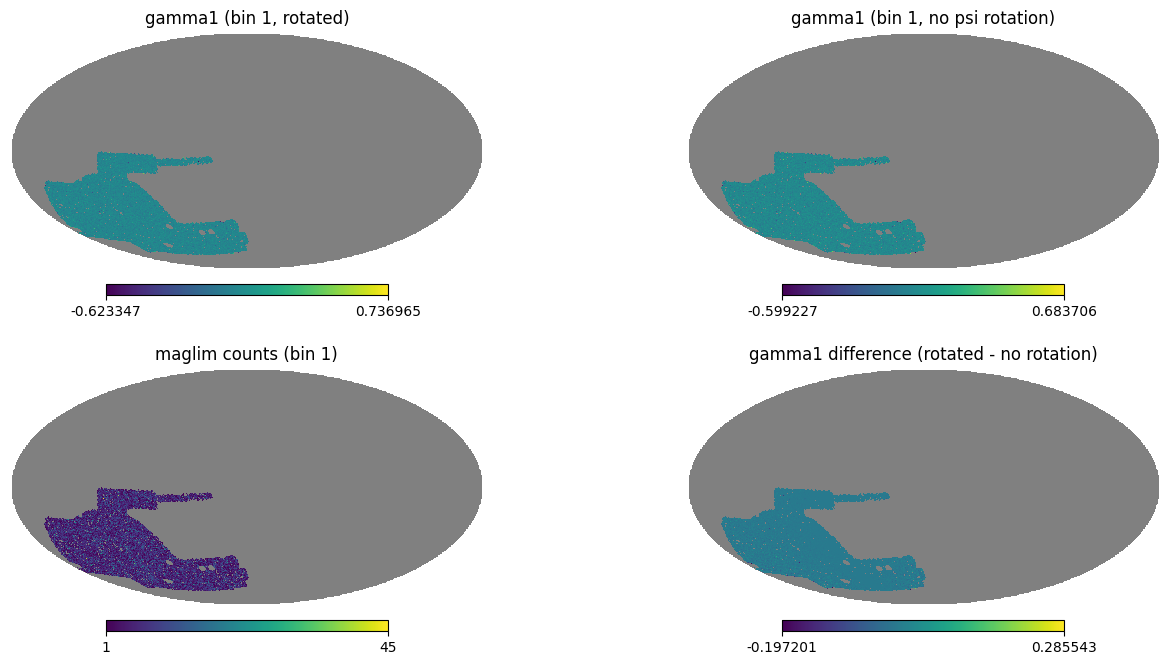

In [5]:
empty = wl_count_map[:, 0] == 0

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plt.axes(axes[0, 0])
m = wl_gamma_map[:, 0, 0].copy()
m[empty] = hp.UNSEEN
hp.mollview(m, title="gamma1 (bin 1, rotated)", hold=True)

plt.axes(axes[0, 1])
m = wl_gamma_map_no_psi_rot[:, 0, 0].copy()
m[empty] = hp.UNSEEN
hp.mollview(m, title="gamma1 (bin 1, no psi rotation)", hold=True)

plt.axes(axes[1, 0])
m = gc_count_map[:, 0].astype(float)
m[m == 0] = hp.UNSEEN
hp.mollview(m, title="maglim counts (bin 1)", hold=True)

plt.axes(axes[1, 1])
m = wl_gamma_map[:, 0, 0] - wl_gamma_map_no_psi_rot[:, 0, 0]
m[empty] = hp.UNSEEN
hp.mollview(m, title="gamma1 difference (rotated - no rotation)", hold=True)

plt.tight_layout()
plt.show()